# ELSS Univariate Data Analysis

## A) Imports & Configuration



In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# inline plotting magic
%matplotlib inline

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,5)

# ---------- Config ----------
CSV_FILE = 'cleaned_elss.csv'  # ensure this CSV sits next to the notebook

# By default we DO NOT save files. Set save_images = True and provide FIG_DIR if you want saving.
save_images = False
FIG_DIR = None

# Performance toggle
fast_mode = False
NAV_BINS = 50 if not fast_mode else 30
RET_BINS = 80 if not fast_mode else 40
TOP_N_SCHEMES = 6 if not fast_mode else 4

print('Config: CSV_FILE=', CSV_FILE)
print('save_images=', save_images, 'fast_mode=', fast_mode)


Config: CSV_FILE= cleaned_elss.csv
save_images= False fast_mode= False


## B) Load & Basic Cleaning

Load the CSV, parse dates, coerce numeric columns, rename NAV column, drop invalid dates and sort. This prepares a clean DataFrame for plotting and analysis.

In [11]:
# B) Load & Basic Cleaning
def load_and_clean(path):
    print('Loading:', path)
    df = pd.read_csv(path, dtype=str)
    # parse date column
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    # numeric columns cleanup
    num_cols = ['NAV', 'Repurchase Price', 'Sale Price']
    for col in num_cols:
        if col in df.columns:
            df[col] = df[col].str.replace(',', '', regex=False)
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # drop rows with invalid dates and sort
    df = df.dropna(subset=['Date']).sort_values(['Scheme Code', 'Date']).reset_index(drop=True)
    df['Scheme Code'] = df['Scheme Code'].astype(str)
    print('Rows after cleaning:', len(df))
    print('Unique schemes:', df['Scheme Code'].nunique())
    return df

df = load_and_clean(CSV_FILE)
df.head(10)


Loading: cleaned_elss.csv
Rows after cleaning: 319355
Unique schemes: 269


,Scheme Code,Scheme Name,ISIN Div Payout/ISIN Growth,ISIN Div Reinvestment,NAV,Date
0,100067,Aditya Birla Sun Life Tax Plan -Regular - IDCW,INF209K01330,INF209K01CM8,70.30,2020-05-04
1,100067,Aditya Birla Sun Life Tax Plan -Regular - IDCW,INF209K01330,INF209K01CM8,69.73,2020-05-05
2,100067,Aditya Birla Sun Life Tax Plan -Regular - IDCW,INF209K01330,INF209K01CM8,70.27,2020-05-06
3,100067,Aditya Birla Sun Life Tax Plan -Regular - IDCW,INF209K01330,INF209K01CM8,69.70,2020-05-07
4,100067,Aditya Birla Sun Life Tax Plan -Regular - IDCW,INF209K01330,INF209K01CM8,69.73,2020-05-08
5,100067,Aditya Birla Sun Life Tax Plan -Regular - IDCW,INF209K01330,INF209K01CM8,69.44,2020-05-11
6,100067,Aditya Birla Sun Life Tax Plan -Regular - IDCW,INF209K01330,INF209K01CM8,68.23,2020-05-12
7,100067,Aditya Birla Sun Life Tax Plan -Regular - IDCW,INF209K01330,INF209K01CM8,69.60,2020-05-13
8,100067,Aditya Birla Sun Life Tax Plan -Regular - IDCW,INF209K01330,INF209K01CM8,68.59,2020-05-14
9,100067,Aditya Birla Sun Life Tax Plan -Regular - IDCW,INF209K01330,INF209K01CM8,68.35,2020-05-15


## C) Summary Statistics (display inline)

Compute descriptive statistics for NAV and display the summary and key percentiles directly in the notebook for easy copying into a report.

In [12]:
nav = pd.to_numeric(df['NAV'], errors='coerce').dropna()

# Full descriptive summary including custom percentiles
desc = nav.describe(
    percentiles=[0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99]
).to_frame().T

# Add skewness and kurtosis
desc['skew'] = nav.skew()
desc['kurtosis'] = nav.kurtosis()  # pandas Fisher definition

print("NAV descriptive summary (below):")
display(desc.T)

# Percentile table
percentiles = nav.quantile(
    [0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99]
).rename_axis('percentile').to_frame('NAV')

print("\nNAV percentiles (below):")
display(percentiles)

# Store in memory for later use
nav_summary_df = desc.copy()
nav_percentiles_df = percentiles.copy()


NAV descriptive summary (below):


,NAV
count,319355.000000
mean,78.204625
std,162.170350
min,0.000000
1%,9.677026
5%,12.330000
10%,14.091000
25%,20.350000
50%,31.358900
75%,63.560000



NAV percentiles (below):


,NAV
percentile,
0.01,9.677026
0.05,12.330000
0.10,14.091000
0.25,20.350000
0.50,31.358900
0.75,63.560000
0.90,145.270000
0.95,311.174200
0.99,925.789800


## D) Returns Computation

Pivot NAV into wide form (Date × Scheme Code) and compute daily percentage returns. We use `fill_method=None` in `pct_change` to avoid pandas FutureWarnings and to compute returns only on actual successive observations.

In [13]:
print("Sorting by Date and Scheme Code...")
df = df.sort_values(['Date', 'Scheme Code'])

# Pivot NAV to wide format
print("Pivoting NAV to wide format...")
nav_wide = df.pivot(index='Date', columns='Scheme Code', values='NAV')

# Compute daily returns
daily_ret_wide = nav_wide.pct_change(fill_method=None)

# Convert to long format for analysis/plots
daily_ret = (
    daily_ret_wide
        .stack()
        .rename('daily_return')
        .reset_index()
        .dropna(subset=['daily_return'])
)

print("Daily return observations (long format):", len(daily_ret))


Sorting by Date and Scheme Code...
Pivoting NAV to wide format...
Daily return observations (long format): 317931


## E) Plot Helpers

A minimal helper is provided to save figures only if saving is enabled. By default `save_images` is False and this helper will do nothing.

In [14]:
def _save_fig(name, out_dir=FIG_DIR):
    """Save the current figure if saving is enabled and directory is provided."""
    if not save_images:
        return
    if out_dir is None:
        raise ValueError('FIG_DIR must be set to save images')
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    fname = f"{ts}_{name}.png"
    path = os.path.join(out_dir, fname)
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight', dpi=300)
    print('Saved figure:', path)


## F) Aggregated Univariate Plots (display inline)

Histogram + KDE for NAV and aggregated daily returns to visualise distributional shape and tails.

Plot: NAV histogram


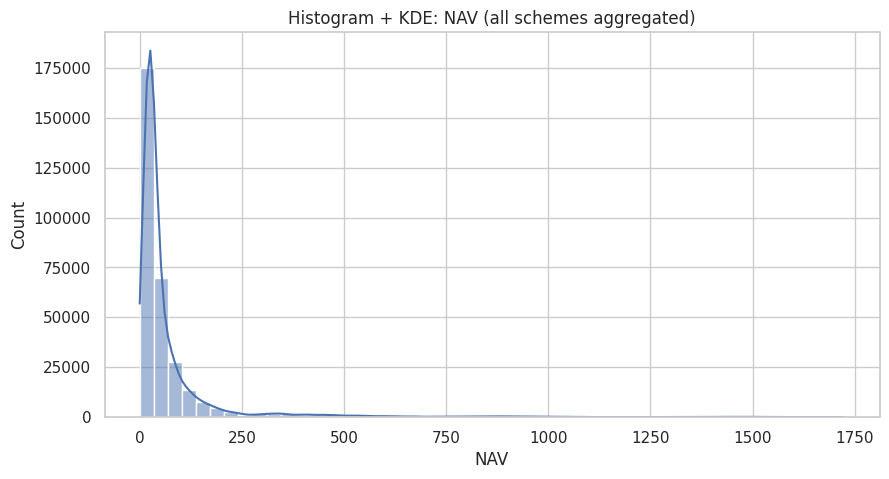

Plot: Daily returns histogram


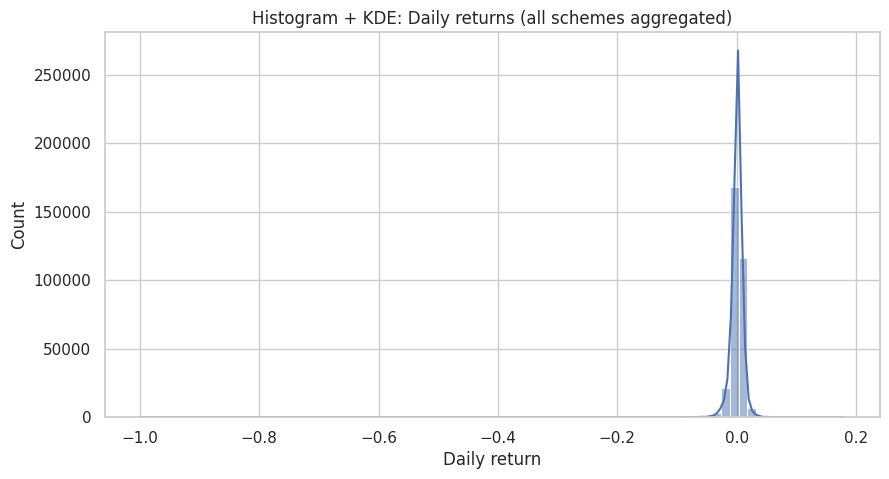

In [15]:
# F) Aggregated univariate plots
print('Plot: NAV histogram')
plt.figure()
sns.histplot(nav, bins=NAV_BINS, kde=True)
plt.title('Histogram + KDE: NAV (all schemes aggregated)')
plt.xlabel('NAV')
plt.ylabel('Count')
plt.show()
plt.close()

print('Plot: Daily returns histogram')
plt.figure()
sns.histplot(daily_ret['daily_return'], bins=RET_BINS, kde=True)
plt.title('Histogram + KDE: Daily returns (all schemes aggregated)')
plt.xlabel('Daily return')
plt.ylabel('Count')
plt.show()
plt.close()


## G) Grouped / Per-scheme Univariate Plots (display inline)

Boxplots and violin plots for top schemes, counts per scheme, and counts per year to inspect scheme-level behaviour and data coverage.

Plot: NAV boxplot for top 6 schemes


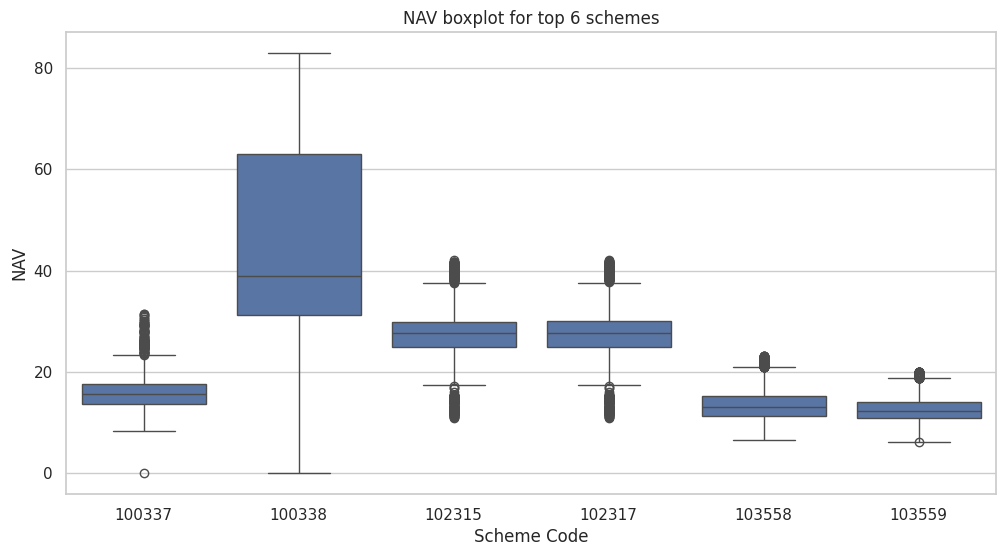

Plot: Violin plot of daily returns (top schemes)


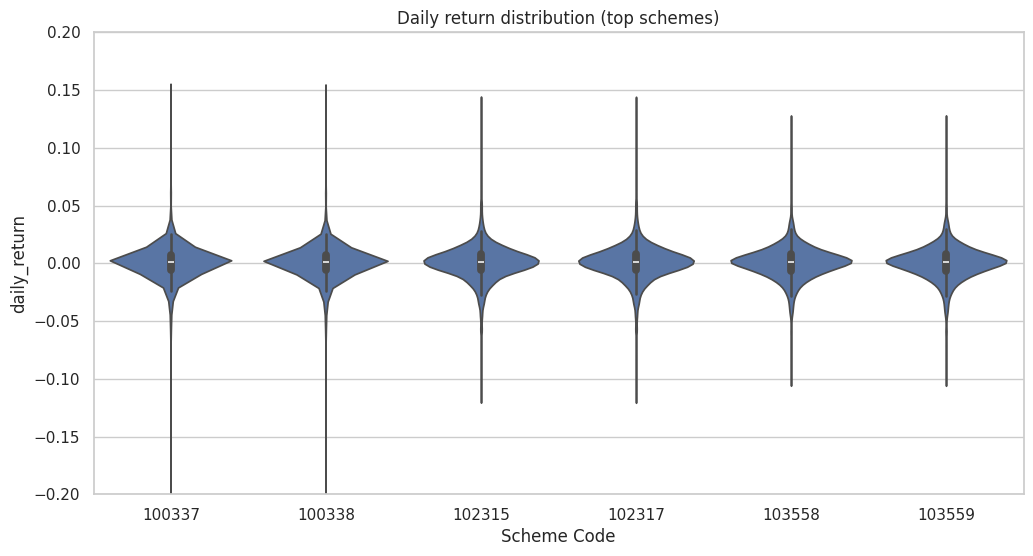

Plot: Count of top 10 schemes


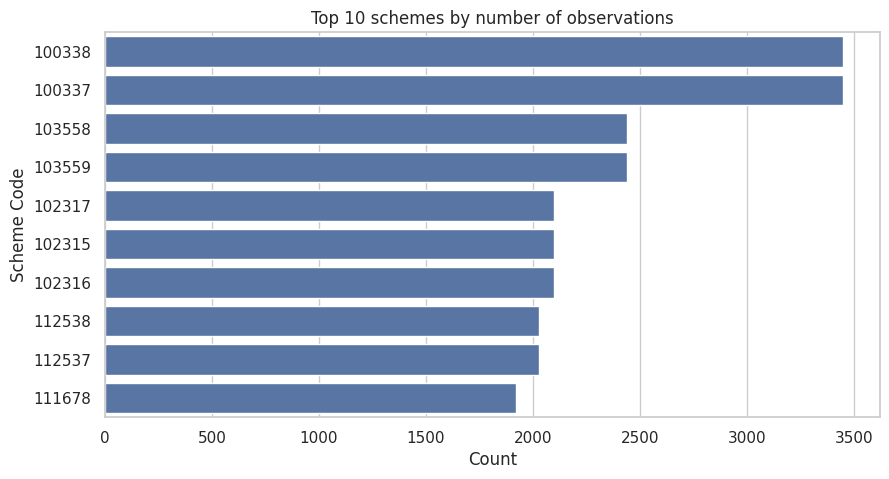

Plot: Observations per Year


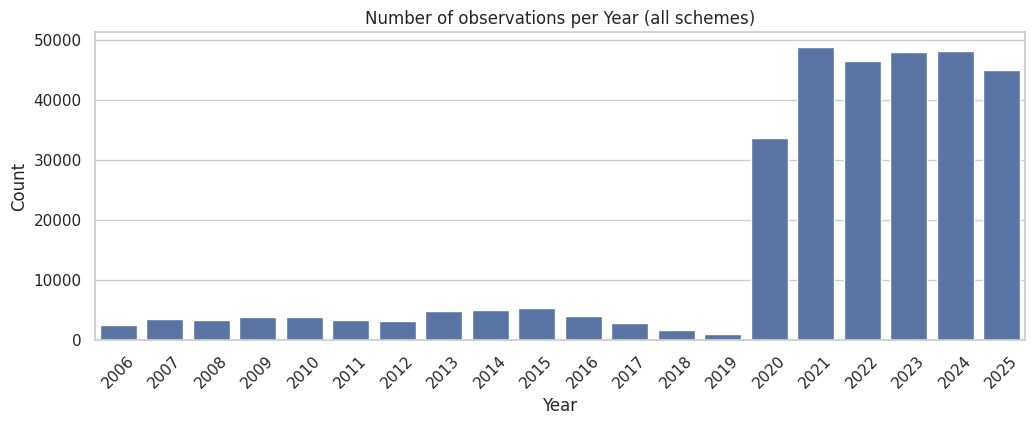

In [16]:
# G) Grouped / per-scheme plots
top_schemes = df['Scheme Code'].value_counts().nlargest(TOP_N_SCHEMES).index.tolist()
print(f'Plot: NAV boxplot for top {len(top_schemes)} schemes')
plt.figure(figsize=(12,6))
sns.boxplot(x='Scheme Code', y='NAV', data=df[df['Scheme Code'].isin(top_schemes)])
plt.title(f'NAV boxplot for top {len(top_schemes)} schemes')
plt.show()
plt.close()

if not fast_mode:
    print('Plot: Violin plot of daily returns (top schemes)')
    plt.figure(figsize=(12,6))
    sns.violinplot(x='Scheme Code', y='daily_return', data=daily_ret[daily_ret['Scheme Code'].isin(top_schemes)])
    plt.title('Daily return distribution (top schemes)')
    plt.ylim(-0.2, 0.2)
    plt.show()
    plt.close()
else:
    print('fast_mode ON: skipping violin plot')

print('Plot: Count of top 10 schemes')
plt.figure(figsize=(10,5))
sns.countplot(y='Scheme Code', data=df, order=df['Scheme Code'].value_counts().nlargest(10).index)
plt.title('Top 10 schemes by number of observations')
plt.xlabel('Count')
plt.ylabel('Scheme Code')
plt.show()
plt.close()

print('Plot: Observations per Year')
df['Year'] = df['Date'].dt.year
plt.figure(figsize=(12,4))
sns.countplot(x='Year', data=df, order=sorted(df['Year'].unique()))
plt.title('Number of observations per Year (all schemes)')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()
plt.close()


## H) IQR Outliers (display inline)

Identify NAV values outside the IQR fences (1.5 × IQR) and display a sample of the outliers inline for inspection. The full set of outliers is kept in memory for further analysis if required.

In [20]:
# H) IQR outliers
Q1 = nav.quantile(0.25)
Q3 = nav.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_nav = df[(df['NAV'] < lower) | (df['NAV'] > upper)]
print(f'IQR fences: lower={lower:.6f}, upper={upper:.6f}')
print(f'Number of NAV outlier rows (IQR method): {len(outliers_nav):,}')

# display a sample to avoid flooding the notebook; show first 50 rows
display(outliers_nav.head(10))

# keep full DataFrame in memory
nav_outliers_df = outliers_nav.copy()


IQR fences: lower=-44.465000, upper=128.375000
Number of NAV outlier rows (IQR method): 36,664


,Scheme Code,Scheme Name,ISIN Div Payout/ISIN Growth,ISIN Div Reinvestment,NAV,Date,Year
1197,100156,Principal Tax Savings Fund,INF173K01361,NaN,164.9200,2020-05-04,2020
14023,100354,ICICI Prudential ELSS Tax Saver Fund - Growth,INF109K01464,NaN,301.8000,2020-05-04,2020
19539,100526,Franklin India ELSS Tax Saver Fund-Growth,INF090I01775,NaN,419.5079,2020-05-04,2020
28239,100998,HDFC Long Term Advantage Plan - Growth Plan,INF179K01996,NaN,279.2750,2020-05-04,2020
30008,101815,Principal Personal Tax Saver Fund,INF173K01353,NaN,153.2000,2020-05-04,2020
30420,101979,HDFC ELSS Tax saver - Growth Plan,INF179K01BB8,NaN,387.9620,2020-05-04,2020
112613,118540,Franklin India ELSS Tax Saver Fund - Direct - ...,INF090I01JS8,NaN,447.8382,2020-05-04,2020
124073,118929,HDFC Long Term Advantage Plan - Growth Option ...,INF179K01WX8,NaN,291.2730,2020-05-04,2020
127886,119060,HDFC ELSS Tax saver - Growth Option - Direct Plan,INF179K01YS4,NaN,405.9240,2020-05-04,2020
140659,119486,Principal Personal Tax Saver Fund - Direct Plan,INF173K01FA4,NaN,159.3900,2020-05-04,2020
